In [1]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames

In [2]:
using Revise
using Newtrinos
using Newtrinos.osc

[ Info: Precompiling Newtrinos [5b289081-bab5-45e8-97fc-86872f1653a0] (cache misses: wrong dep version loaded (2), include_dependency fhash change (2))
[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0xd4a4e6a0236ea0a1, 0x8262c1a64c6b9862, 0x2f8396263a5e6b09, 0x38a6d0d856f68025, 0x43fb72cd3a615367, 0xe4cebeabcfb6d38c, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), BAT._NoADSelected())


In [28]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}(NND(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.1, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 25.0, r = 1.0), (m₀ = Uniform{Float64}(a=0.001, b=2.0), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = Uniform{Float64}(a=1.0, b=100.0), r = Uniform{Float64}(a=0.0, b=1.0)), Newtrinos.osc.var"#get_Nnaturalness#50"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}(OscillationConf

In [29]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [30]:
experiments = (

  juno= Newtrinos.juno.configure(physics),
);

[ Info: Loading juno data


In [31]:
p = Newtrinos.get_params(experiments)

(N = 25.0, juno_accidental_norm = 1.0, juno_atmnc_norm = 1.0, juno_co_norm = 1.0, juno_detection_epsilon = 1.0, juno_fast_neutron_norm = 1.0, juno_geo_rate_norm = 1.0, juno_geo_shape_eps = 0.0, juno_lihe_norm = 1.0, juno_res_a = 0.0261, juno_res_b = 0.0082, juno_res_c = 0.0123, juno_world_reactor_norm = 1.0, junotao_energy_scale = 1.0, junotao_flux_scale = 1.0, junotao_shape_eps = 0.0, m₀ = 0.1, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [32]:
using Setfield
using CairoMakie

In [33]:
# modify the value of m0 with a random value taken from a Distribution

sigma= 2*p.m₀/10
new_m₀_un = rand(Uniform(p.m₀, p.m₀*(1+2/p.r))) 
new_m₀_norm= rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*(1+2/p.r)))
p_new_un = @set p.m₀ = new_m₀_un
p_new_norm = @set p.m₀ = new_m₀_norm


(N = 25.0, juno_accidental_norm = 1.0, juno_atmnc_norm = 1.0, juno_co_norm = 1.0, juno_detection_epsilon = 1.0, juno_fast_neutron_norm = 1.0, juno_geo_rate_norm = 1.0, juno_geo_shape_eps = 0.0, juno_lihe_norm = 1.0, juno_res_a = 0.0261, juno_res_b = 0.0082, juno_res_c = 0.0123, juno_world_reactor_norm = 1.0, junotao_energy_scale = 1.0, junotao_flux_scale = 1.0, junotao_shape_eps = 0.0, m₀ = 0.11745891413960202, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [34]:
assets= experiments.juno.assets

(visible_to_neutrino_interp = 65-element extrapolate(interpolate((::Vector{Float64},), ::Vector{Float64}, Gridded(Linear())), Flat()) with element type Float64:
 1.8055709847970536
 1.8531830525211386
 1.8722278796107727
 1.89908504597914
 1.9456710691435752
 1.9755163652821492
 2.0361069966467116
 2.0820089901047134
 2.137091382254315
 2.1462717809459155
 2.2013541730955173
 2.2564365652451195
 2.3115189573947212
 ⋮
 6.8099143162788796
 6.9568006953444845
 7.131228270484891
 7.348497706186099
 7.535165812915305
 7.737134584130513
 7.939103355345719
 8.141072126560928
 8.343040897776135
 8.550517908206299
 8.717727169865665
 8.927526281141354, no_osc_interp = 65-element extrapolate(interpolate((::Vector{Float64},), ::Vector{Float64}, Gridded(Linear())), 0) with element type Float64:
  13.537376275037532
  95.62164937544527
 151.5927904728713
 228.70837353867216
 298.3535182304651
 360.39142969384324
 444.48645756071636
 507.7566030686267
 572.3712175722616
 622.9552928950469
 698.19529

In [35]:
expected_un = mean(Newtrinos.juno.get_forward_model(physics, assets)(p_new_un))
expected_un_var = var(Newtrinos.juno.get_forward_model(physics, assets)(p_new_un))


376-element Vector{Float64}:
  66.15922923251075
  90.34307913308726
 123.28717452811857
 158.08098077650524
 196.47302537679147
 232.17778462445676
 261.5108591824853
 288.64605991262806
 312.19705872754724
 332.5865163763308
 352.61841949819694
 367.5231515779336
 379.8226389773635
   ⋮
   5.039041554056231
   4.9423455588163625
   4.862019988820355
   4.795911258890856
   4.741966064102837
   4.698252945562561
   4.662996293049245
   4.6346105913134075
   4.611724141511847
   4.593186640915155
   4.57806062171193
   4.565600618704303

In [36]:
expected_norm = mean(Newtrinos.juno.get_forward_model(physics, assets)(p_new_norm))
expected_norm_var = var(Newtrinos.juno.get_forward_model(physics, assets)(p_new_norm))


376-element Vector{Float64}:
  66.16463332951358
  90.35480965923328
 123.30950116553632
 158.12130623822878
 196.53143054674464
 232.22747884877205
 261.5102977123218
 288.57990085928793
 312.08577259995815
 332.45385275804347
 352.469175950412
 367.36155019939144
 379.6620271617275
   ⋮
   5.037406382304784
   4.94080765951863
   4.860583775186665
   4.794574655487905
   4.74072144361527
   4.697088823272145
   4.661899332028901
   4.633567494290731
   4.610723128603519
   4.592218374910125
   4.577118587632715
   4.564681059822812

In [37]:
# standard model for comparison
osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc, atm_flux, earth_layers);

experiments_SM = (

  juno= Newtrinos.juno.configure(physics_SM),

);

p_SM = Newtrinos.get_params(experiments_SM)



[ Info: Loading juno data


(juno_accidental_norm = 1.0, juno_atmnc_norm = 1.0, juno_co_norm = 1.0, juno_detection_epsilon = 1.0, juno_fast_neutron_norm = 1.0, juno_geo_rate_norm = 1.0, juno_geo_shape_eps = 0.0, juno_lihe_norm = 1.0, juno_res_a = 0.0261, juno_res_b = 0.0082, juno_res_c = 0.0123, juno_world_reactor_norm = 1.0, junotao_energy_scale = 1.0, junotao_flux_scale = 1.0, junotao_shape_eps = 0.0, m₀ = 0.1, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [38]:
asimov_data= Newtrinos.generate_asimov_data(experiments_SM.juno, p_SM)
observed = Float64.(asimov_data)

[ Info: Poisson-based model. Rounding Asimov data to nearest integer.


376-element Vector{Float64}:
  66.0
  91.0
 124.0
 159.0
 198.0
 233.0
 263.0
 290.0
 314.0
 334.0
 354.0
 369.0
 382.0
   ⋮
   5.0
   5.0
   5.0
   5.0
   5.0
   5.0
   5.0
   5.0
   5.0
   5.0
   5.0
   5.0

In [39]:
likelihood_SM=-Newtrinos.logdensityof(Newtrinos.juno.get_forward_model(physics_SM, assets)(p_SM), observed)

1322.344201668906

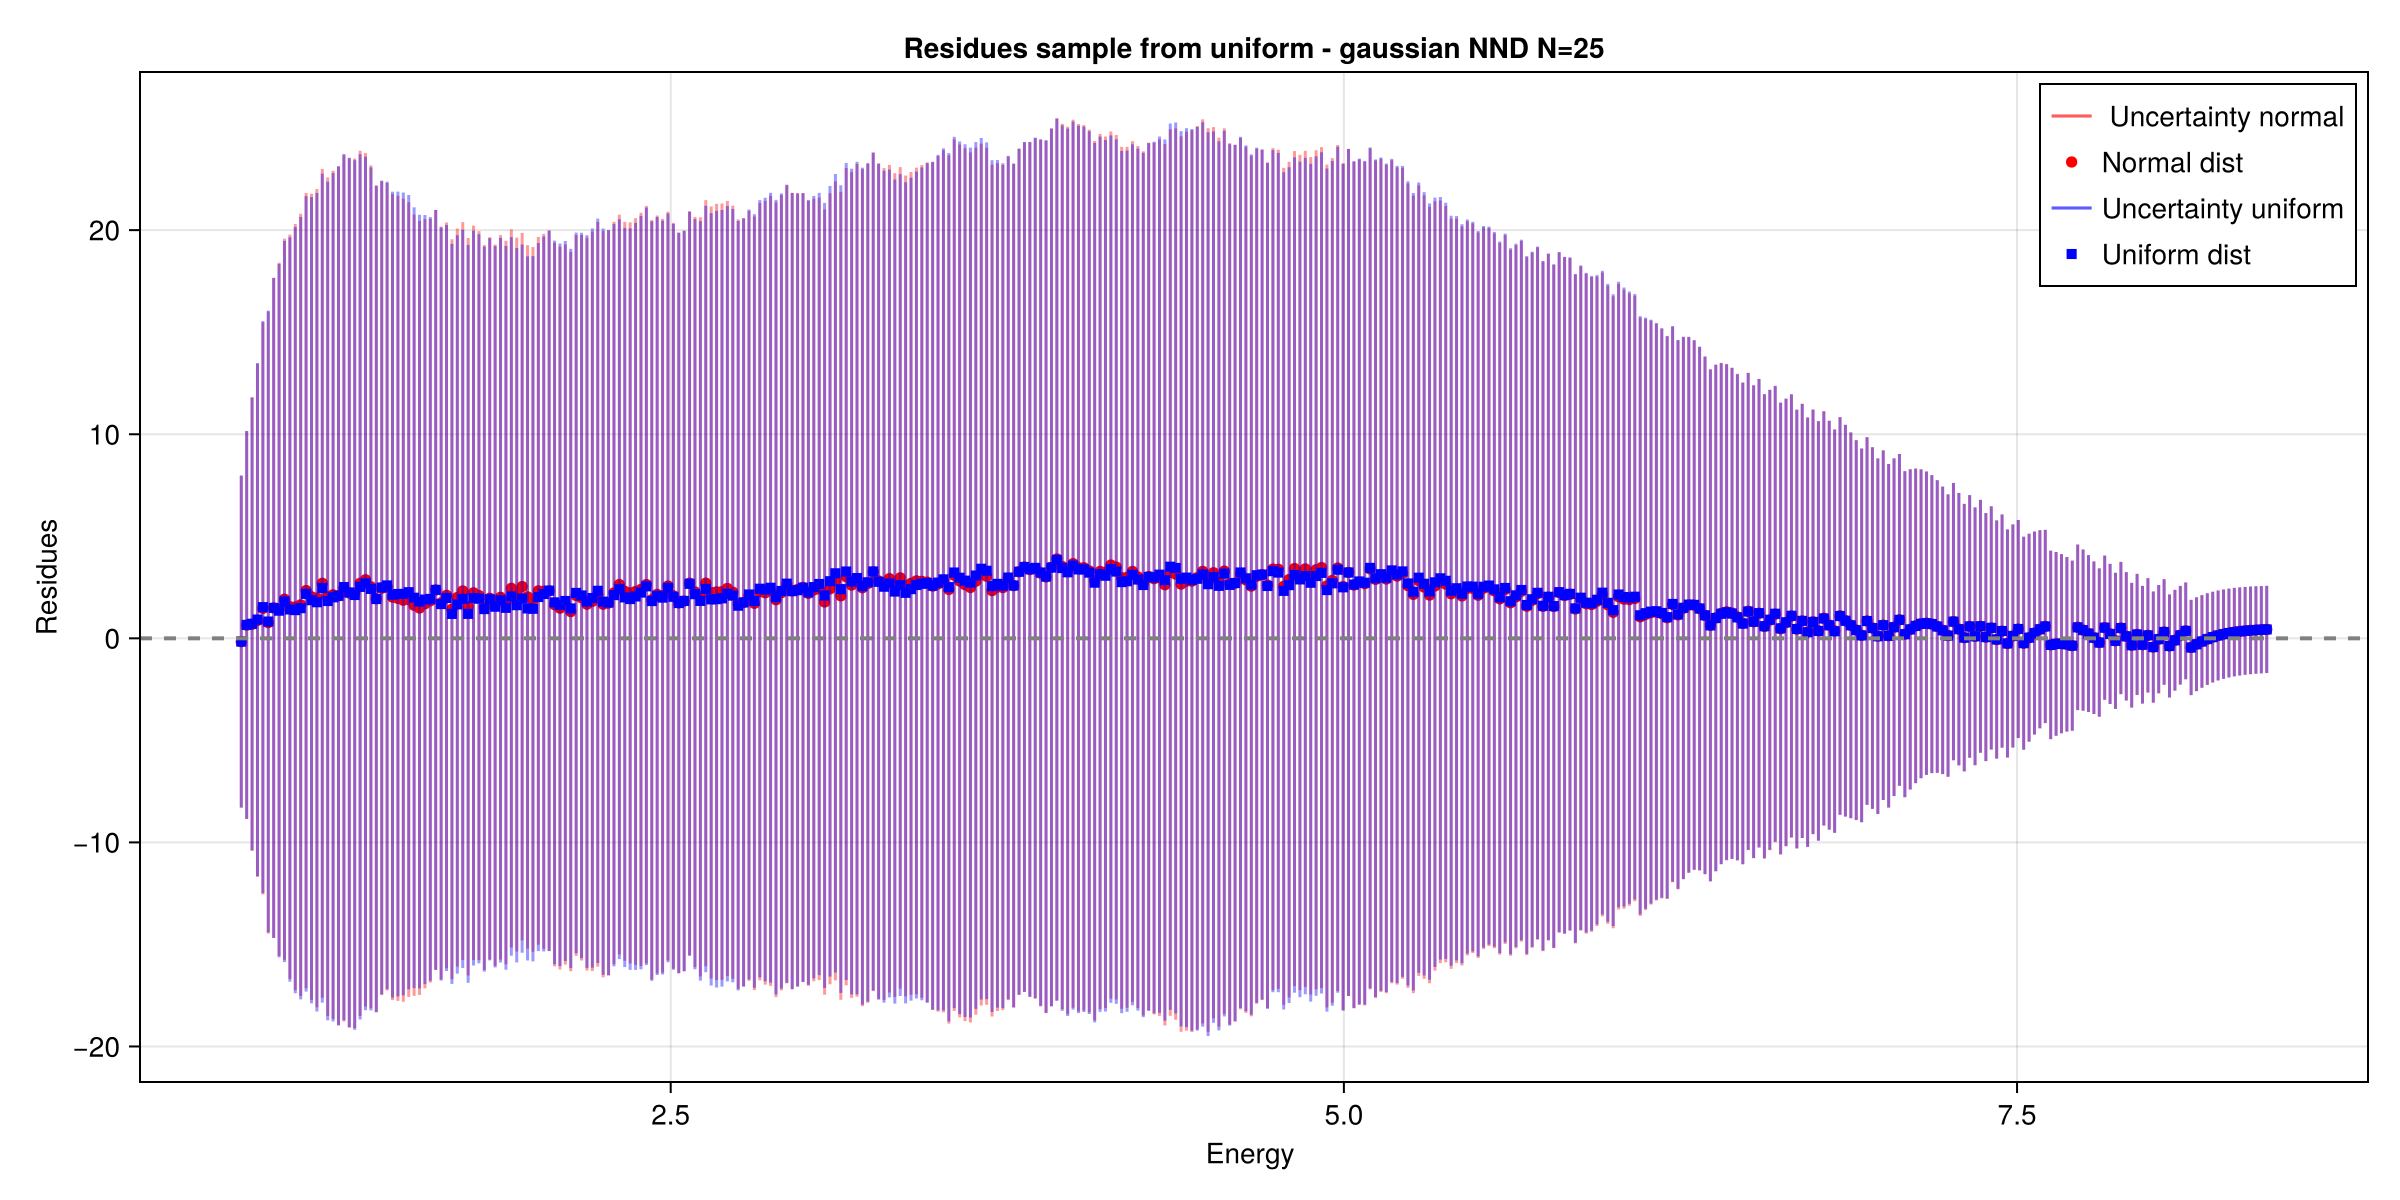

CairoMakie.Screen{IMAGE}


In [40]:

# Create the figure
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "Energy ",
    ylabel = "Residues", 
    title = "Residues sample from uniform - gaussian NND N=25")


errorbars!(ax, assets.E_bins_visible,  observed-expected_norm,  sqrt.(expected_norm_var), 
      color = (:red, 0.4), label = " Uncertainty normal")

scatter!(ax, assets.E_bins_visible,  observed-expected_norm, 
        color = :red, markersize = 8, label = "Normal dist")

errorbars!(ax, assets.E_bins_visible,  observed-expected_un,sqrt.(expected_un_var), 
      color = (:blue, 0.4), label = "Uncertainty uniform")

scatter!(ax, assets.E_bins_visible, observed-expected_un, 
        color = :blue, marker = :rect, markersize = 8,label = "Uniform dist")

        
# Add a horizontal line at zero for reference
hlines!(ax, [0], color = :gray, linestyle = :dash, linewidth = 2)

    
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/dayabay/nm_dayabay_NNM_N30_residues.png", fig)

In [41]:
#img = experiments.dayabay.plot(p_new_norm)
#display("image/png", img)

In [42]:

using ProgressMeter
using MeasureBase

In [43]:
function random_sampling(physics, experiments, p)

   chi_squared_un_list = Float64[]
   chi_squared_norm_list = Float64[]

   @showprogress for i in 1:100
      #println("Random sampling iteration: $i")
      sigma=2*p.m₀/1000
      new_m₀_un = rand(Uniform(p.m₀, p.m₀*(1+2/p.r))) 
      new_m₀_norm=rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*(1+2/p.r)))
      p_new_un = @set p.m₀ = new_m₀_un
      p_new_norm = @set p.m₀ =new_m₀_norm

      assets= experiments.juno.assets
   

      expected_un = mean(Newtrinos.juno.get_forward_model(physics, assets)(p_new_un))
      expected_un_var = var(Newtrinos.juno.get_forward_model(physics, assets)(p_new_un))
      expected_norm = mean(Newtrinos.juno.get_forward_model(physics, assets)(p_new_norm))
      expected_norm_var = var(Newtrinos.juno.get_forward_model(physics, assets)(p_new_norm))

      #chi_squared_un = sum((observed.- expected_un).^2 ./ expected_un_var)
      #chi_squared_norm = sum((observed.- expected_norm).^2 ./ expected_norm_var)
      likelihood_norm=logdensityof(Newtrinos.juno.get_forward_model(physics, assets)(p_new_norm), observed)
      likelihood_un=logdensityof(Newtrinos.juno.get_forward_model(physics, assets)(p_new_un), observed)

      push!(chi_squared_un_list, likelihood_un)
      push!(chi_squared_norm_list, likelihood_norm)

   end
   return chi_squared_un_list, chi_squared_norm_list
end

random_sampling (generic function with 1 method)

In [44]:
trial=random_sampling(physics, experiments, p)

Progress: 100%|█████████████████████████████████████████| Time: 0:18:59


([-1324.584400501803, -1324.6177213269566, -1324.5704085931375, -1324.6317632294945, -1324.6441291267893, -1324.6140772751733, -1324.5429250295049, -1324.5602086281326, -1324.5347709525895, -1324.5541730131597  …  -1324.5446713084248, -1324.6022818066492, -1324.5385688660524, -1324.5992520434509, -1324.6150013973818, -1324.6159443688364, -1324.5358701240652, -1324.538311810687, -1324.6455972854314, -1324.6073135215775], [-1324.515834934236, -1324.5470881274189, -1324.6764614795193, -1324.620695069487, -1324.5840164468186, -1324.5651000701125, -1324.5880773151646, -1324.5771293232526, -1324.5468065584637, -1324.565146704099  …  -1324.6063184192726, -1324.6736673681964, -1324.6049517472807, -1324.5724299877083, -1324.6085282396307, -1324.5850580731983, -1324.543845542601, -1324.564706704779, -1324.5645246262966, -1324.57340659565])

In [45]:
trial=.-trial # to have the negative log likelihood

([1324.584400501803, 1324.6177213269566, 1324.5704085931375, 1324.6317632294945, 1324.6441291267893, 1324.6140772751733, 1324.5429250295049, 1324.5602086281326, 1324.5347709525895, 1324.5541730131597  …  1324.5446713084248, 1324.6022818066492, 1324.5385688660524, 1324.5992520434509, 1324.6150013973818, 1324.6159443688364, 1324.5358701240652, 1324.538311810687, 1324.6455972854314, 1324.6073135215775], [1324.515834934236, 1324.5470881274189, 1324.6764614795193, 1324.620695069487, 1324.5840164468186, 1324.5651000701125, 1324.5880773151646, 1324.5771293232526, 1324.5468065584637, 1324.565146704099  …  1324.6063184192726, 1324.6736673681964, 1324.6049517472807, 1324.5724299877083, 1324.6085282396307, 1324.5850580731983, 1324.543845542601, 1324.564706704779, 1324.5645246262966, 1324.57340659565])

In [46]:
mean_un=mean(trial[1])
mean_norm=mean(trial[2])

1324.5835354003443

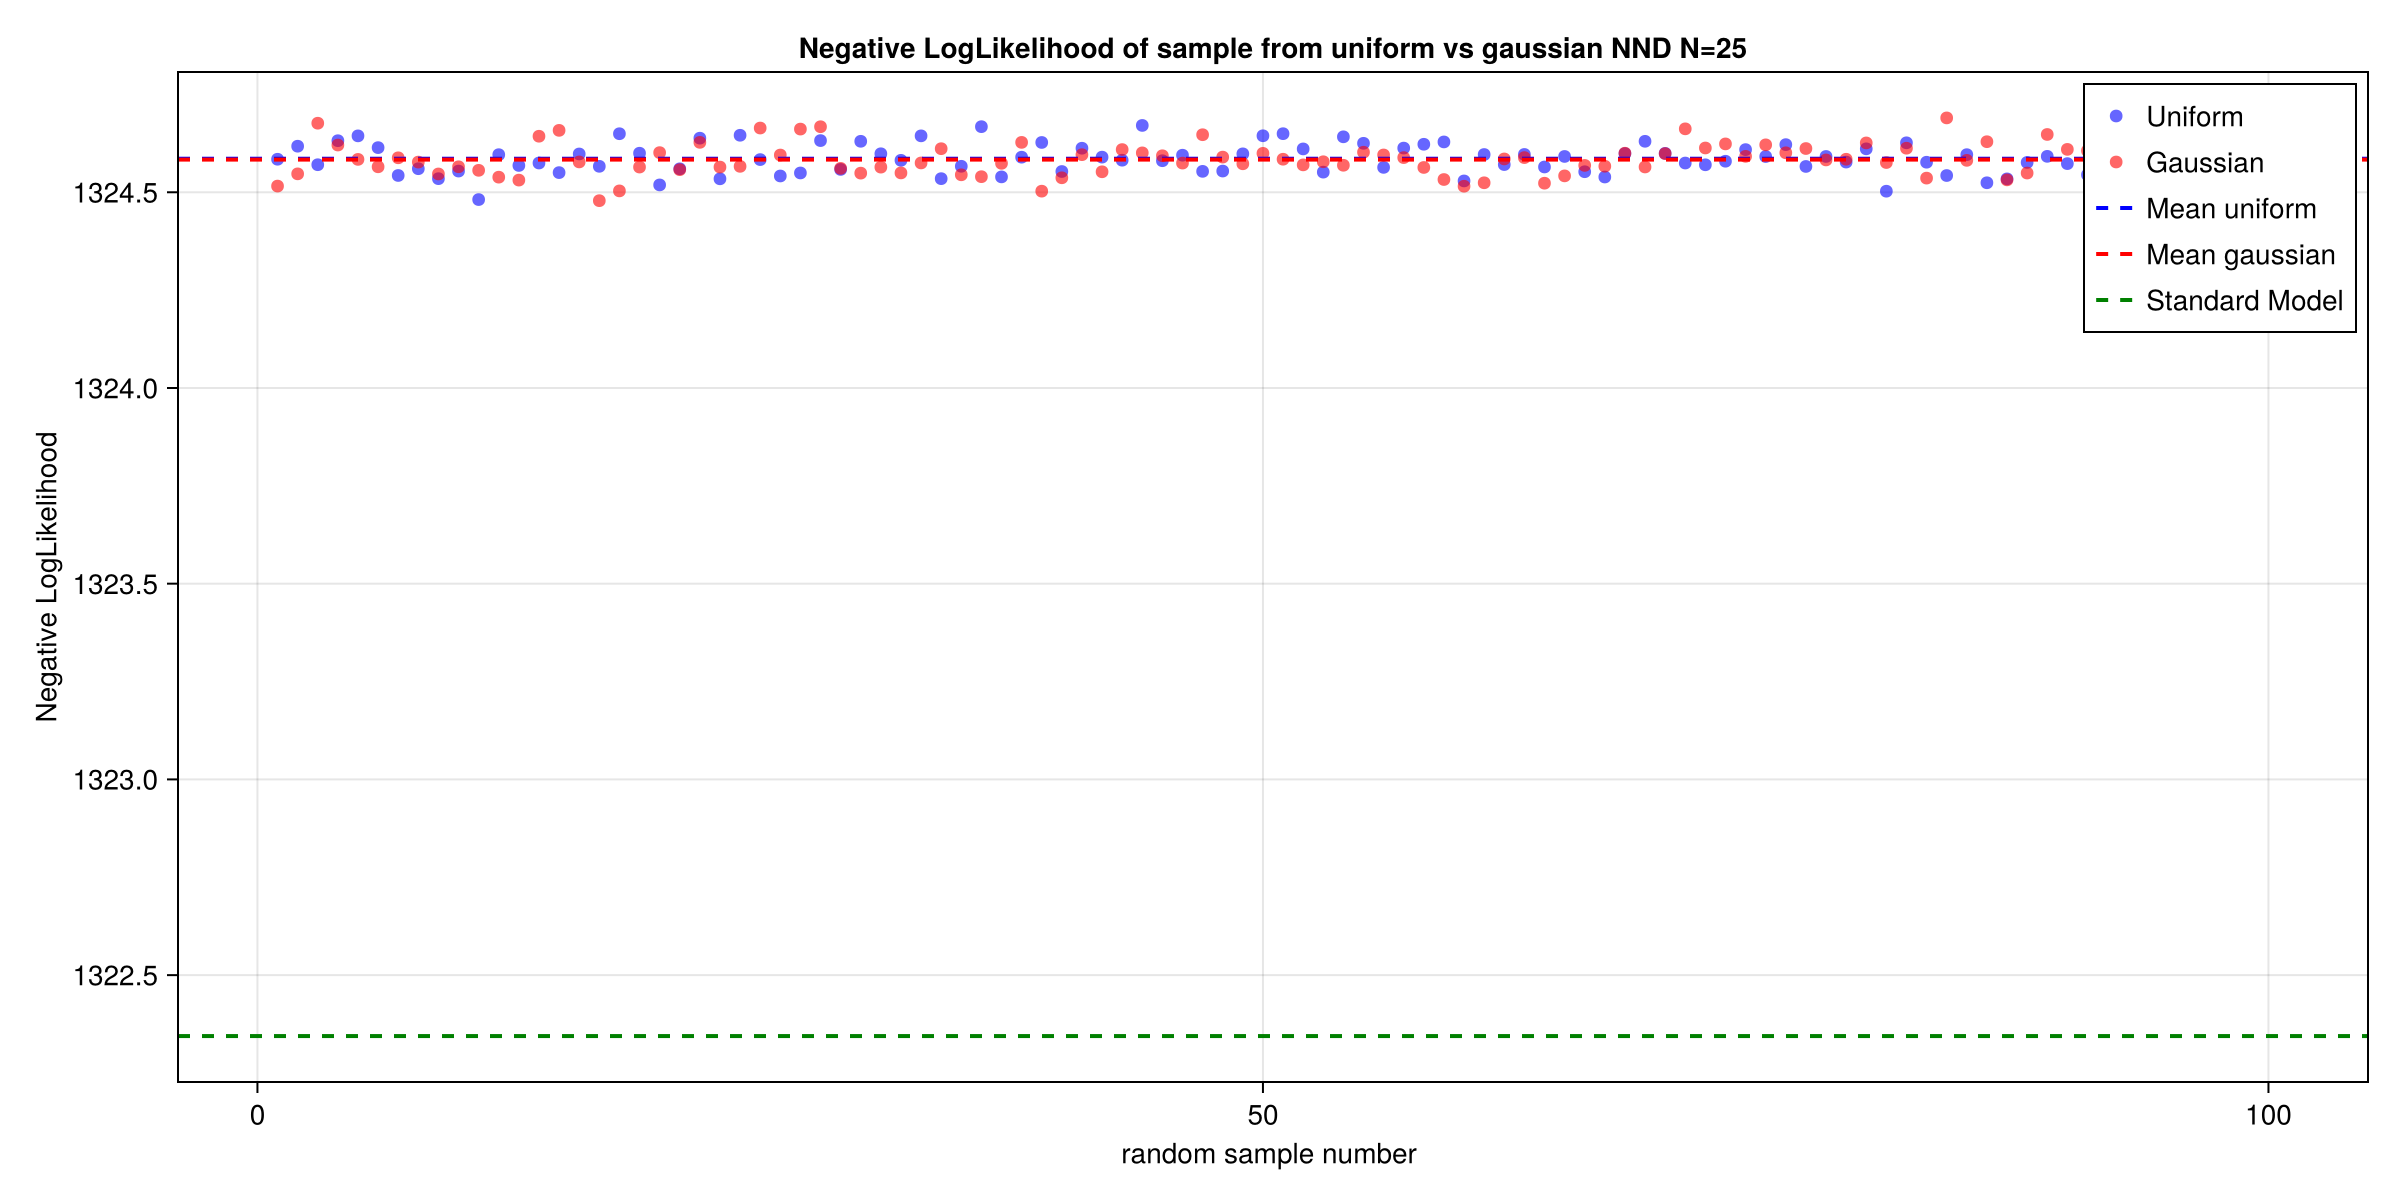

In [47]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "random sample number ",
    ylabel = "Negative LogLikelihood", 
    title = "Negative LogLikelihood of sample from uniform vs gaussian NND N=25")
scatter!(ax, 1:100, trial[1], color = (:blue, 0.6), label = "Uniform")
scatter!(ax, 1:100, trial[2], color = (:red, 0.6), label = "Gaussian")


hlines!(ax, [mean_un], color = :blue, linestyle = :dash, linewidth = 2, label = "Mean uniform")
hlines!(ax, [mean_norm], color = :red, linestyle = :dash, linewidth = 2, label = "Mean gaussian")
hlines!(ax, likelihood_SM, color = :green, linestyle = :dash, linewidth = 2, label = "Standard Model")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/juno_samples_NND_N25_m0=0.1.png", fig)

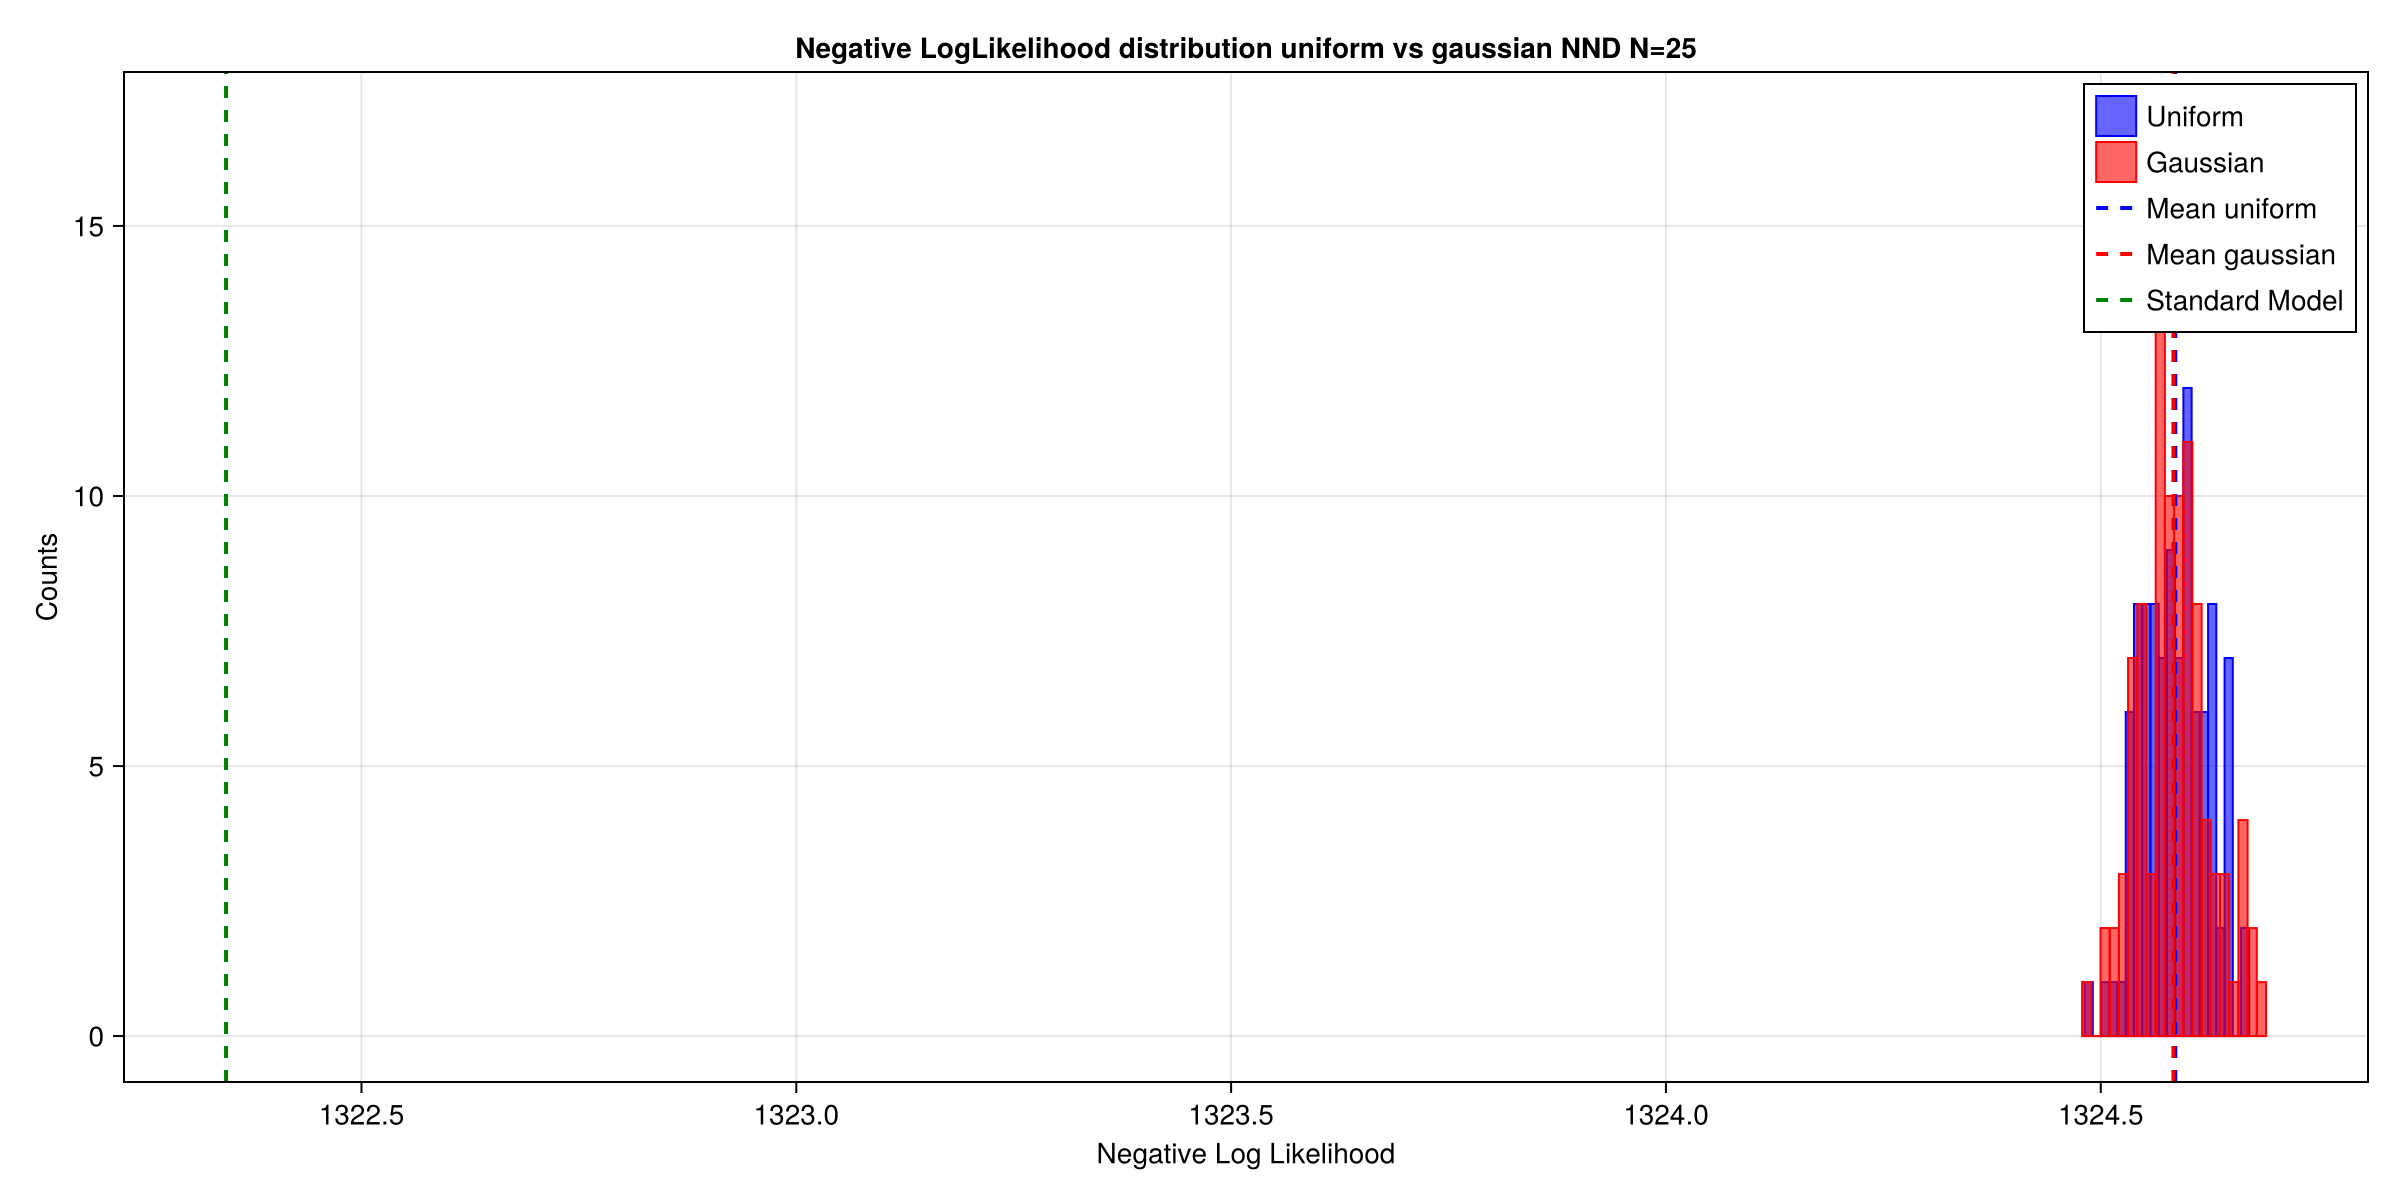

In [48]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = " Negative Log Likelihood ",
    ylabel = "Counts", 
    title = "Negative LogLikelihood distribution uniform vs gaussian NND N=25")

hist!(ax, trial[1], bins = 20, color = (:blue, 0.6), strokewidth = 1, strokecolor = :blue, label = "Uniform")
hist!(ax, trial[2], bins = 20, color = (:red, 0.6), strokewidth = 1, strokecolor = :red, label = "Gaussian")



vlines!(ax, [mean_un], color = :blue, linestyle = :dash, linewidth = 2, label = "Mean uniform")
vlines!(ax, [mean_norm], color = :red, linestyle = :dash, linewidth = 2, label = "Mean gaussian")
vlines!(ax, likelihood_SM, color = :green, linestyle = :dash, linewidth = 2, label = "Standard Model")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

display(fig)

save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/juno_nll_NND_N25_m0=0.1.png", fig)